## Benchmark with DeepLabCut and SuperAnimal

In [15]:
from mask_to_box_labelimg import convert_masks, visualize

import os
import glob
from math import ceil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np


def vis_frames_in_a_dir(label_vis_dir, n_frames=10, figsize=(12, 8), equal_spacing=True):
    """Plot up to `n_frames` images from `label_vis_dir` in a grid.

    Args:
        label_vis_dir (str): Path containing visualization images (png/jpg).
        n_frames (int): Number of frames to display.
        figsize (tuple): Matplotlib figure size.
        equal_spacing (bool): If True, select frames evenly spaced across the directory.
    """
    if not os.path.isdir(label_vis_dir):
        raise FileNotFoundError(f"Directory does not exist: {label_vis_dir}")

    patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for p in patterns:
        files.extend(glob.glob(os.path.join(label_vis_dir, p)))

    if len(files) == 0:
        raise FileNotFoundError(f"No image files found in: {label_vis_dir}")

    files = sorted(files)
    n_total = len(files)
    n_show = min(n_total, max(1, int(n_frames)))

    if equal_spacing and n_total > n_show:
        indices = np.linspace(0, n_total - 1, n_show, dtype=int)
        files = [files[i] for i in indices]
    else:
        files = files[:n_show]

    cols = min(n_show, 3)
    rows = ceil(n_show / cols)

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flatten() if n_show > 1 else [axs]

    for i in range(rows * cols):
        ax = axs[i]
        if i < n_show:
            img_path = files[i]
            try:
                img = mpimg.imread(img_path)
            except Exception:
                from PIL import Image
                img = Image.open(img_path)
            ax.imshow(img)
            fname = os.path.basename(img_path)
            if len(fname) > 40:
                fname = fname[:37] + '...'
            ax.set_title(fname, fontsize=8)
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


### 1. Firstly, we convert the boundbox from SAM2Mice format to labelimg format bounding box and visualize it

In [6]:
DATA_DIR = "/mnt/nas02/LAR/pico/SAM2/benchmark/five_mice_openfield/"  # change to your data directory after downloading the data

frames_dir = DATA_DIR + "openfield_five_mouse/"
pickle_file = DATA_DIR + "openfield_five_mouse_seg/segment_masks.pickle"
output_dir = DATA_DIR + "openfield_five_mouse_seg/SAM2Mice_yolo_labels/"
label_vis_dir = DATA_DIR + "openfield_five_mouse_seg/SAM2Mice_label_vis/"

convert_masks(
            pickle_path=pickle_file,
            out_dir=output_dir,
            img_h=1024,
            img_w=1224,
            fmt="yolo",
            min_area=900,
            num_classes=5
        )

visualize(
            images_dir=frames_dir,
            labels_dir=output_dir,
            out_dir=label_vis_dir,
            fmt="yolo",
            conf_thr=0.5,
        )


Visualizing: 100%|██████████| 1000/1000 [02:24<00:00,  6.93it/s]


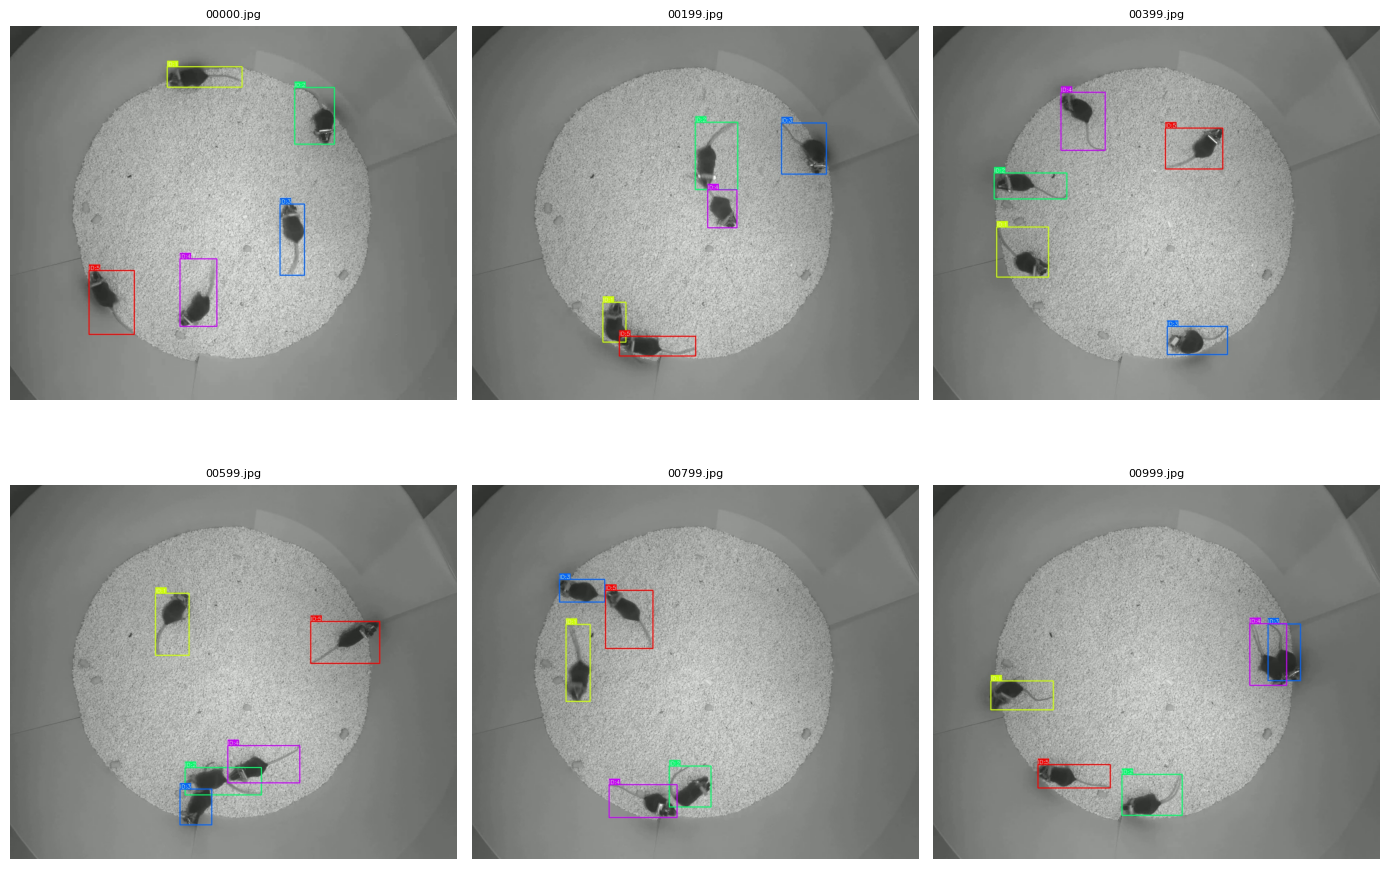

In [16]:
vis_frames_in_a_dir(label_vis_dir, n_frames=6, figsize=(14,10))

### 2. Compute the MOTA metrics for SAM2Mice, SuperAnimal and DeepLabCut respectively

In [23]:
from compute_metrics import compute_mot_metrics, print_results

DATA_DIR = "/mnt/nas02/LAR/pico/SAM2/benchmark/five_mice_openfield/"

superanimal_pred = DATA_DIR + "SuperAnimal_output/openfield_five_mouse_superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2_hrnet_w32.h5"
five_mouse_dlc_trained = DATA_DIR + "DLC_trained_output/openfield_five_mouseDLC_resnet50_PICO_five_miceJun26shuffle0_50000_el_filtered.h5"

SAM2 = DATA_DIR + "openfield_five_mouse_seg/SAM2Mice_yolo_labels/"
GT_dir_bounding_box = DATA_DIR + "ground_truth_bb_labels"

save_dir ="five_mouse_benchmark_results"
os.makedirs(save_dir, exist_ok=True)

results_superanimal, _ = compute_mot_metrics(
    GT_dir_bounding_box,
    superanimal_pred,
    tracker_type="bbox",
    margin=5.0,
    yolo_img_shape=(1224, 1024),
    match_in_first_frame=False,
    save_path=os.path.join(save_dir, "superanimal.pkl")

)
print("SuperAnimal Results:")
print_results(results_superanimal)


results_five_mouse_trained_dlc, _ = compute_mot_metrics(
    GT_dir_bounding_box,
    five_mouse_dlc_trained,
    tracker_type="bbox",
    margin=5.0,
    yolo_img_shape=(1224, 1024),
    match_in_first_frame=False,
    save_path=os.path.join(save_dir, "trained_dlc.pkl")
)
print("Trained DLC Results:")
print_results(results_five_mouse_trained_dlc)


results_SAM2, _ = compute_mot_metrics(
    GT_dir_bounding_box,
    SAM2,
    tracker_type="bbox",
    margin=5.0,
    yolo_img_shape=(1224, 1024),
    match_in_first_frame=False,
    save_path=os.path.join(save_dir, "sam2_mice.pkl")
)
print("SAM2Mice Results:")
print_results(results_SAM2)



Computing MOT metrics...
MOT Evaluation Results
  MOTA: 0.178
  Recall: 0.482
  FN (False Negatives): 2589
  IDF1: 0.169
  IDP: 0.247
  IDR: 0.128
  ID switches (IDs): 1342
  MT (Mostly Tracked): 0
  FM (Fragmentations): 661

Detailed summary:
                num_frames      idf1       idp    idr  recall  precision  \
MOT_Evaluation        1000  0.168621  0.247009  0.128  0.4822   0.930529   

                num_objects  mostly_tracked  partially_tracked  mostly_lost  \
MOT_Evaluation         5000               0                  5            0   

                num_false_positives  num_misses  num_switches  \
MOT_Evaluation                  180        2589          1342   

                num_fragmentations    mota      motp  num_transfer  \
MOT_Evaluation                 661  0.1778  0.163577          1252   

                num_ascend  num_migrate  
MOT_Evaluation           3            3  
SuperAnimal Results:
MOT Evaluation Results
  MOTA: 0.178
  Recall: 0.482
  FN (False Ne

### 3. Plot the metrics results

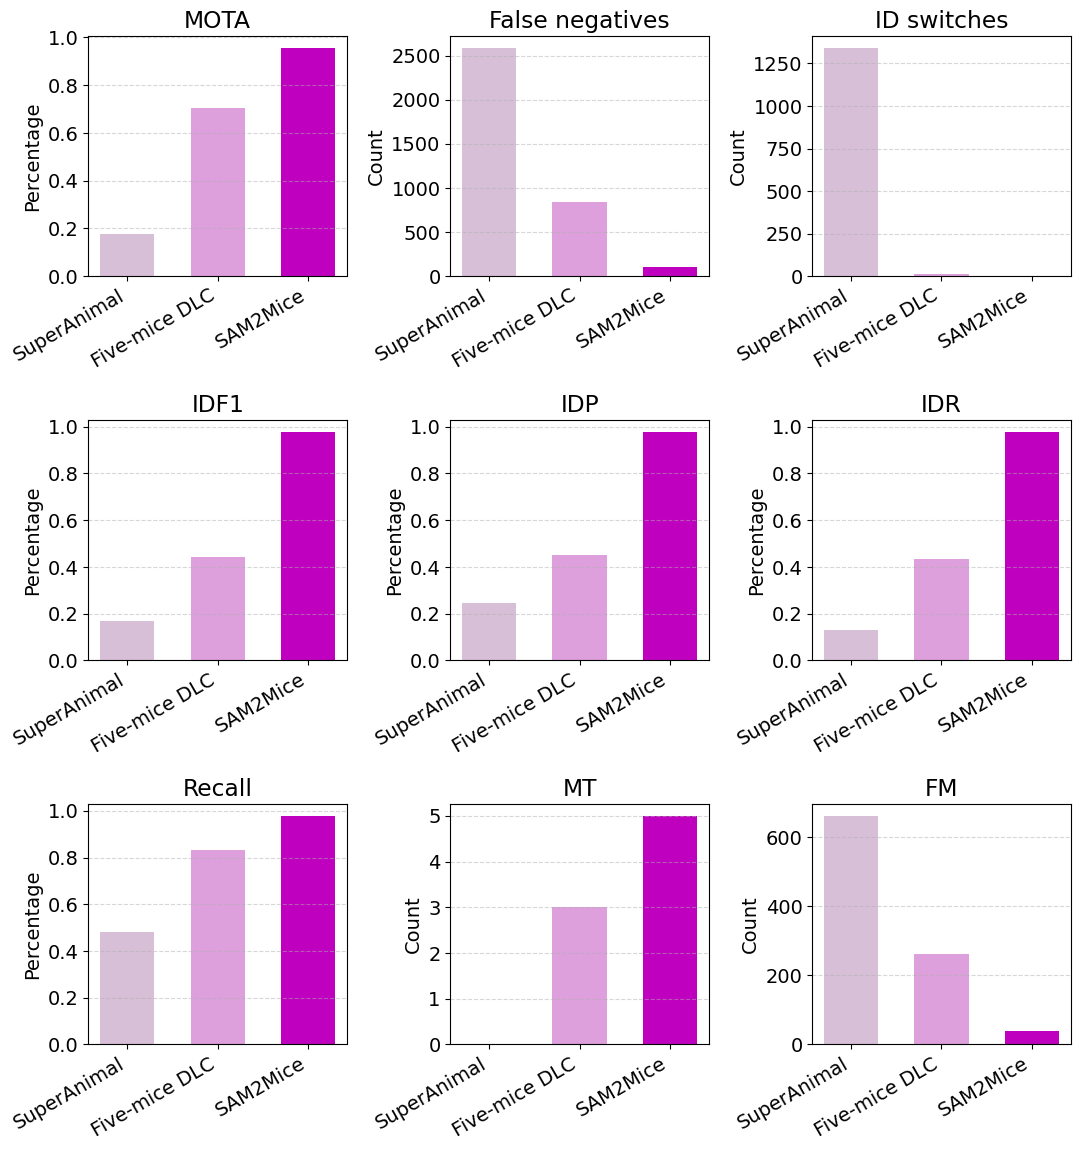

In [31]:
methods = {
    'SuperAnimal': results_superanimal,
    'Five-mice DLC': results_five_mouse_trained_dlc,
    'SAM2Mice': results_SAM2,
}

metrics = [
    ('MOTA', 'MOTA', 'Percentage'),
    ('FN', 'False negatives','Count'),
    ('IDs', "ID switches",  'Count'),
    ('IDF1','IDF1', 'Percentage'),
    ('IDP', 'IDP','Percentage'),
    ('IDR', 'IDR','Percentage'),
    ('Rcll', 'Recall', 'Percentage'),
    ('MT', 'MT','Count'),
    ('FM', 'FM', 'Count'),
]


n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
fig.tight_layout(pad=4)

colors = ['thistle', "plum", "m"]

for idx, (metric, metric_full, ylabel) in enumerate(metrics):
    ax = axes[idx // n_cols, idx % n_cols]
    x = np.arange(len(methods))
    width = 0.6

    vals = [methods[m].get(metric, 0) for m in methods]
    ax.bar(x, vals, width, label=list(methods.keys()), color=colors[:len(methods)])

    ax.set_xticks(x)
    ax.set_xticklabels(methods.keys(), rotation=30, ha='right')
    ax.set_title(metric_full)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
total_plots = n_rows * n_cols
for idx in range(len(metrics), total_plots):
    fig.delaxes(axes[idx // n_cols, idx % n_cols])

plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()